[Variable Glossary](#Variable-Glossary)
<br>
[Visualizing each feature](#Visualizing-each-feature)
<br>
[Correlation Matricies](#correlation-matricies)
<br>
[Crosstabs](#crosstabs)
<br>
[Data Cleaning](#correlation-matricies)
<br>
[Data Prep](#moving-on-to-the-rest-of-the-data-prep)
<br>
[Building Models](#moving-back-to-building-models)

# Variable Glossary
- definition
- correlation
- scatterplot

In [1]:
import pandas as pd
import numpy as np
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import chi2_contingency

In [3]:
filename = "celiac_disease_lab_data.csv"
df = pd.read_csv(filename)
df.head(20)

,Age,Gender,Diabetes,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Marsh,cd_type,Disease_Diagnose
0,10,Male,Yes,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,marsh type 0,potential,yes
1,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,marsh type 3a,atypical,yes
2,8,Female,Yes,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,marsh type 1,latent,yes
3,10,Male,Yes,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,marsh type 3a,silent,yes
4,9,Male,Yes,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,marsh type 1,latent,yes
5,8,Female,Yes,Type 1,fatty,yes,Variant,yes,yes,1.10,9.5,1.00,marsh type 3a,silent,yes
6,9,Male,Yes,Type 1,watery,yes,Variant,yes,yes,2.10,11.4,1.00,marsh type 2,typical,yes
7,5,Female,Yes,Type 1,fatty,yes,PSS,yes,yes,0.80,12.0,0.98,marsh type 1,latent,yes
8,6,Female,Yes,Type 1,fatty,yes,PSS,yes,yes,1.50,8.0,1.10,marsh type 3b,silent,yes
9,4,Male,Yes,Type 1,watery,yes,Variant,yes,yes,0.42,11.5,1.00,marsh type 2,typical,yes


In [4]:
df.dtypes

Age                   int64
Gender               object
Diabetes             object
Diabetes_Type        object
Diarrhea             object
Abdominal            object
Short_Stature        object
Sticky_Stool         object
Weight_loss          object
IgA                 float64
IgG                 float64
IgM                 float64
Marsh                object
cd_type              object
Disease_Diagnose     object
dtype: object

In [5]:
df["Diabetes_Type"] = df["Diabetes_Type"].fillna(0)

In [6]:
df.isna().sum()

Age                 0
Gender              0
Diabetes            0
Diabetes_Type       0
Diarrhea            0
Abdominal           0
Short_Stature       0
Sticky_Stool        0
Weight_loss         0
IgA                 0
IgG                 0
IgM                 0
Marsh               0
cd_type             0
Disease_Diagnose    0
dtype: int64

In [7]:
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(include=['object'])

Visualizing Correlations Between Variables: 
- using a correlation matrix for numeric variables
- using Cramer's V to measure correlation between categorical variables (derived from chi-square)
- using correlation ratio for correlation between categorical and numeric variables (how much of the numeric variation can be explained by the categorical variable's groups)

In [8]:
# starting with age
df['Age'].describe()

count    2206.000000
mean       12.768812
std         7.434250
min         1.000000
25%         8.000000
50%        10.000000
75%        15.000000
max        35.000000
Name: Age, dtype: float64

In [9]:
df['IgA'].describe()

count    2206.000000
mean        1.427384
std         1.110042
min         0.340000
25%         1.000000
50%         1.100000
75%         1.800000
max         9.000000
Name: IgA, dtype: float64

In [10]:
df['IgG'].describe()

count    2206.000000
mean       10.052901
std         2.047683
min         5.000000
25%         8.700000
50%        10.000000
75%        12.000000
max        15.300000
Name: IgG, dtype: float64

In [11]:
df['IgM'].describe()

count    2206.000000
mean        1.236963
std         0.447216
min         0.500000
25%         0.980000
50%         1.100000
75%         1.500000
max         2.700000
Name: IgM, dtype: float64

In [12]:
df['Marsh'].describe()

count              2206
unique                7
top       marsh type 3b
freq                445
Name: Marsh, dtype: object

In [13]:
df['Disease_Diagnose'].describe()

count     2206
unique       2
top        yes
freq      1843
Name: Disease_Diagnose, dtype: object

# Visualizing each feature

Starting with numeric features. I tried scatterplots first, and even jittered, they just didn't show anything useful. Box plots and histograms show a lot more about the data. I liked histograms the best.


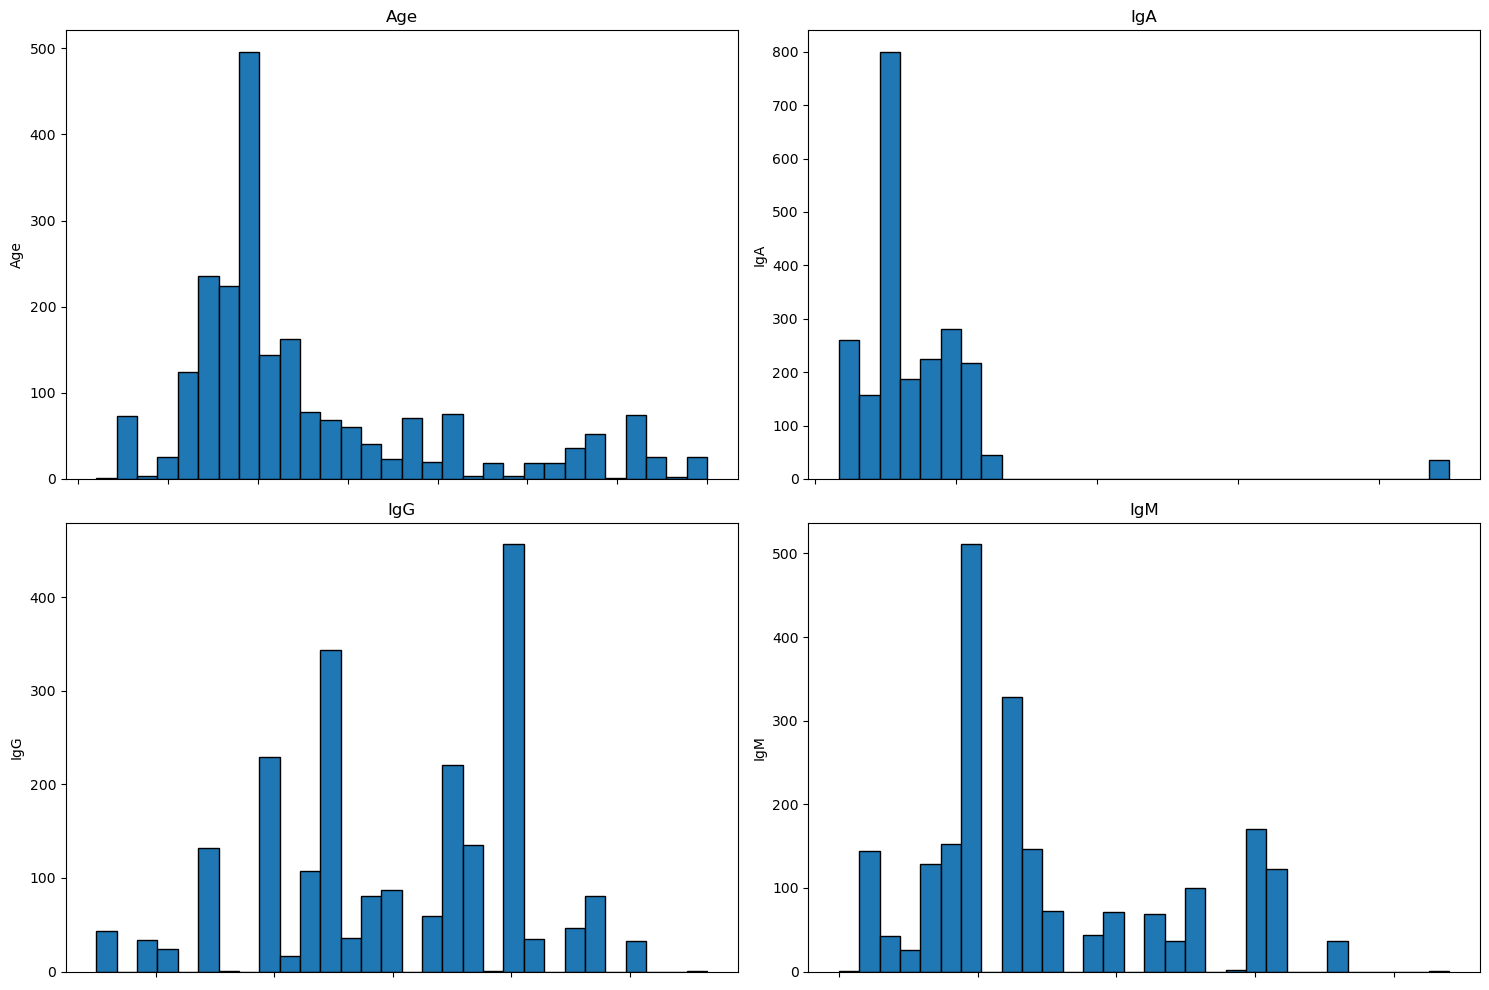

In [14]:
n_features = len(df_num.columns)
ncols = 2
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))   
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    #axes[i].boxplot(df_num[col])
    #axes[i].scatter(range(len(df_num[col])), df_num[col], alpha=0.5)
    axes[i].hist(df_num[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)  
    axes[i].set_xticklabels('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Next, visualize the spread of the categorical variables. We're going to plot using count plots.

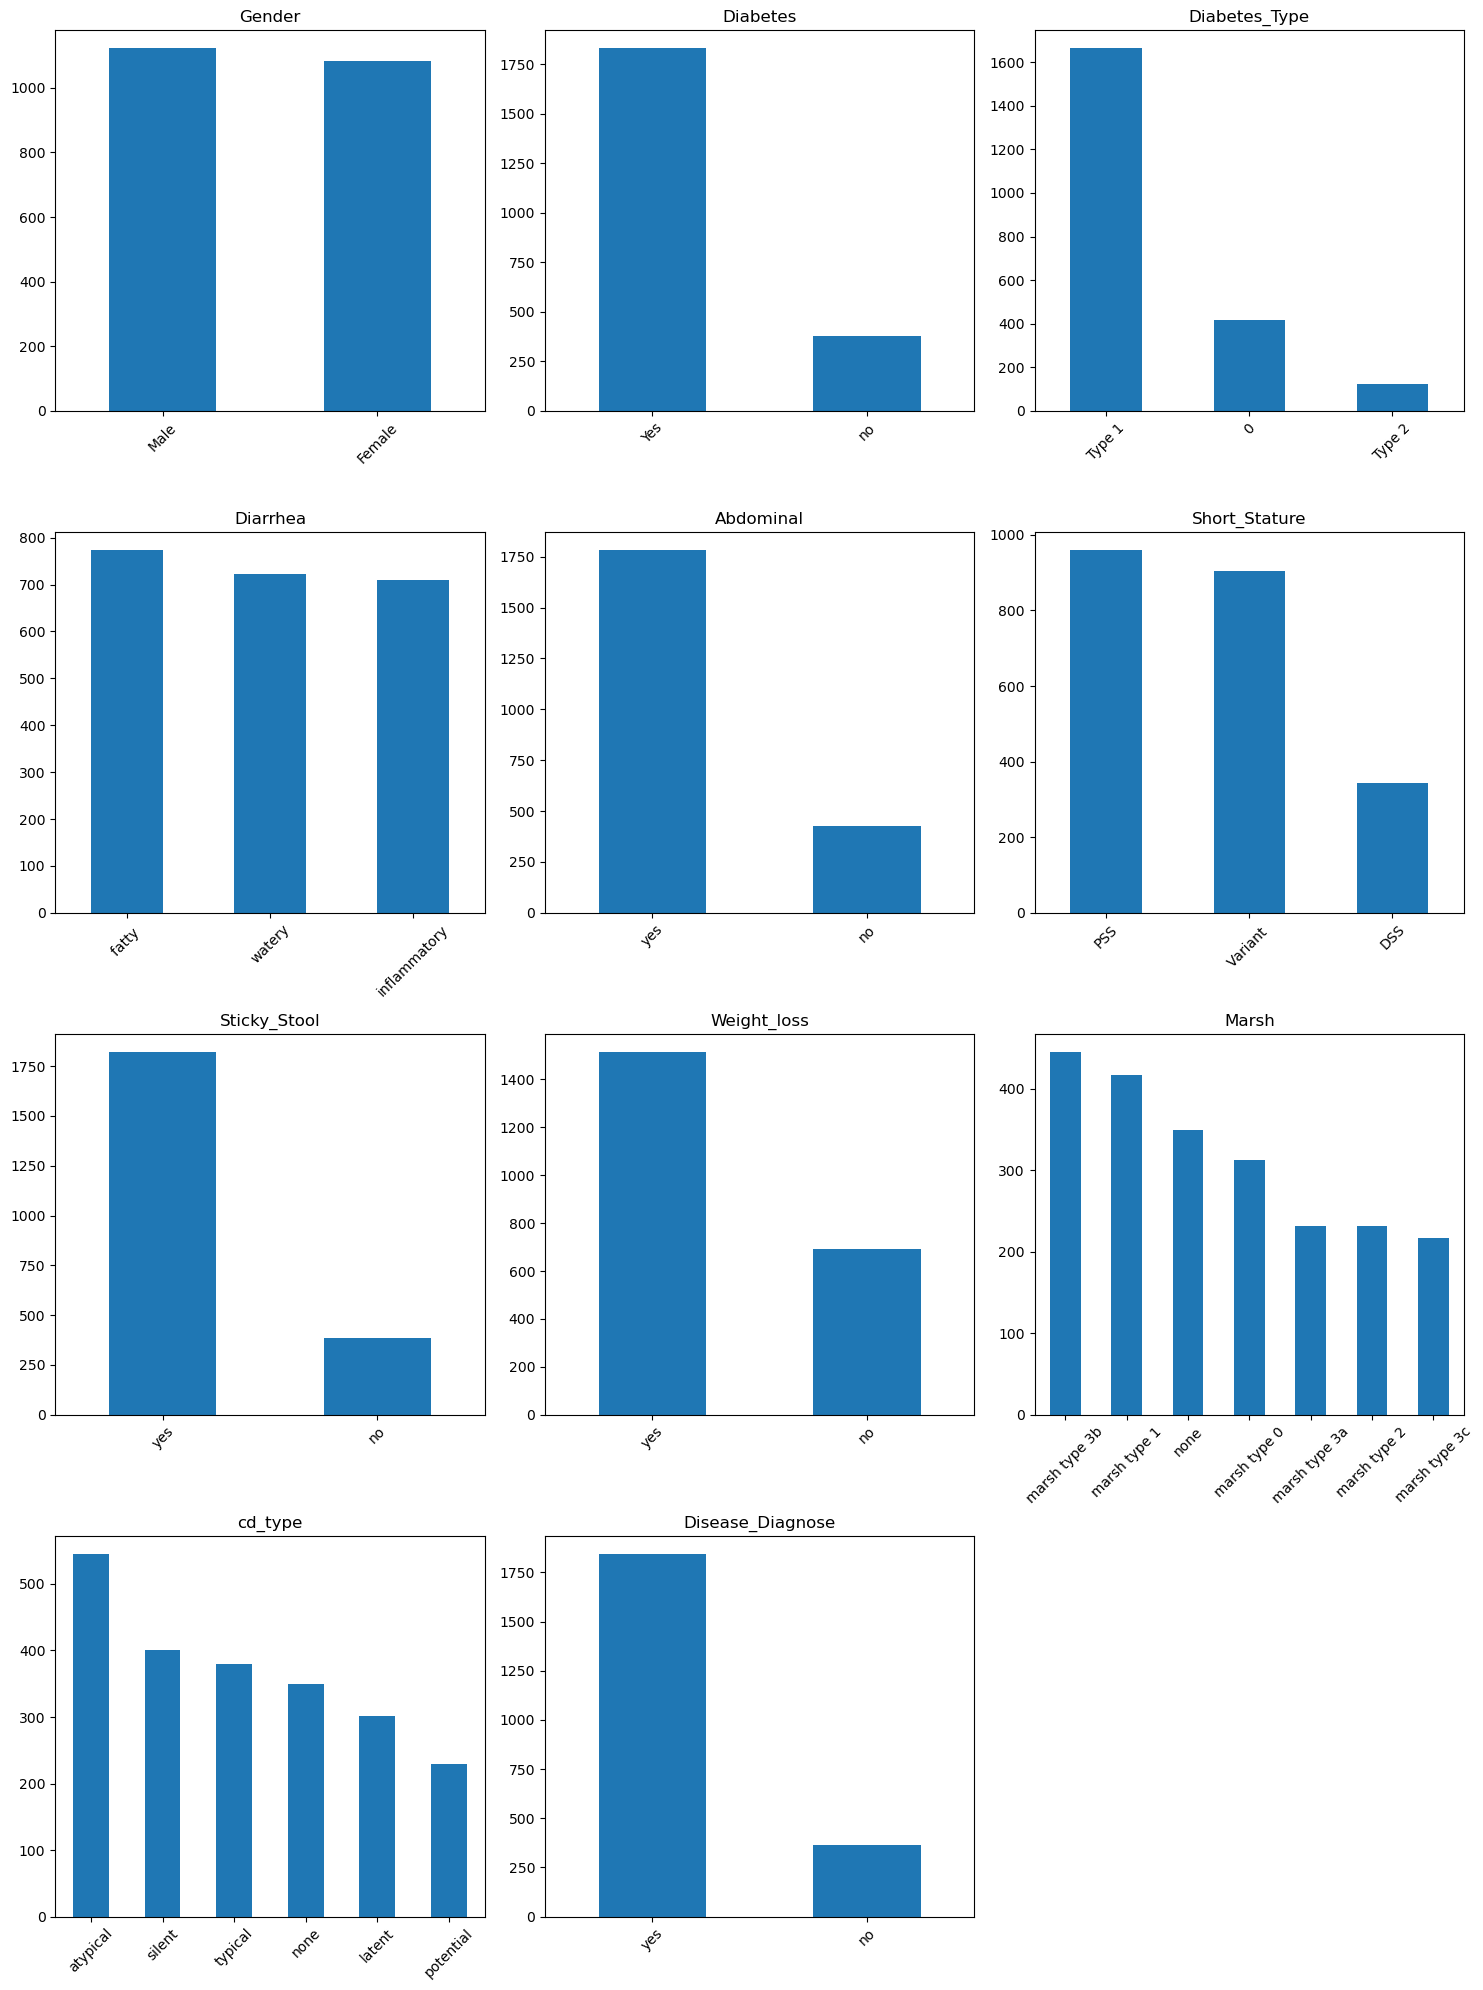

In [15]:
n_features = len(df_cat.columns)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    df_cat[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# Correlation Matricies

<Axes: >

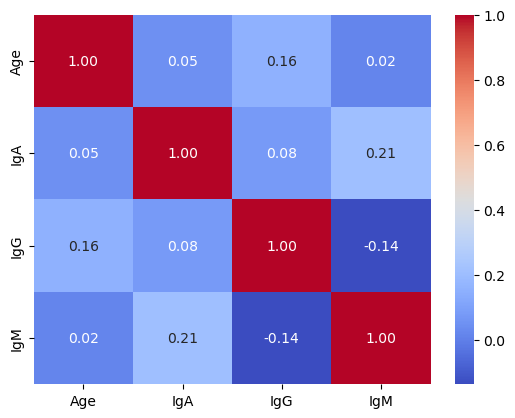

In [16]:
# correlation matrix for numeric variables
correlation_matrix = df_num.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

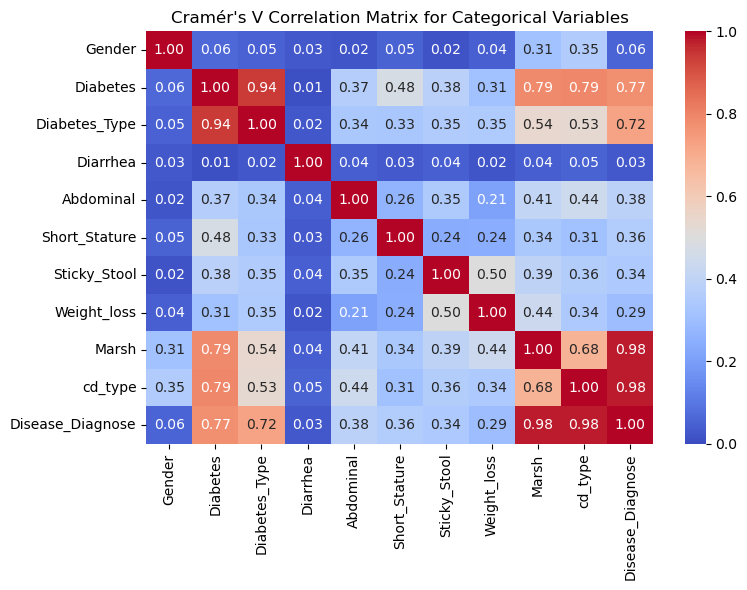

In [17]:
# cramer's v for categorical variables
cramers_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_cat.columns))),
    columns=df_cat.columns,
    index=df_cat.columns
)

for col1 in df_cat.columns:
    for col2 in df_cat.columns:
        contingency_table = pd.crosstab(df_cat[col1], df_cat[col2])
        chi2 = chi2_contingency(contingency_table)[0]
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        cramers_matrix.loc[col1, col2] = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

plt.figure(figsize=(8,6))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0) 
plt.title("Cramér's V Correlation Matrix for Categorical Variables")
plt.tight_layout()
plt.show()


Mixed results here - definitely reinforces that I have to drop marsh and cd_type. marsh almost is disease_diagnose, which makes sense. same with diabetes and diabetes_type. Think I can drop diabetes. Interesting that gender has a much higher correlation with marsh and cd_type than it does with disease_diagnose. Not exactly sure what that means.

In [18]:
df_num.isnull().sum()

Age    0
IgA    0
IgG    0
IgM    0
dtype: int64

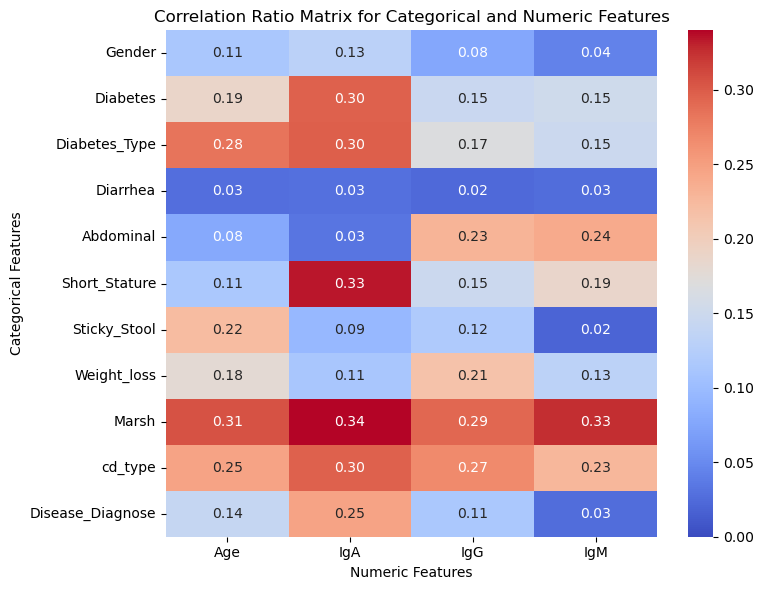

In [19]:
# correlation ratio
mix_matrix = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_num.columns))), 
    columns = df_num.columns,
    index = df_cat.columns
)
for cat_col in df_cat.columns:
    for num_col in df_num.columns:
        categories = np.array(df_cat[cat_col].astype(str))
        values = np.array(df_num[num_col])

        # handle nan values
        mask = ~np.isnan(values) | pd.isna(values)
        categories = categories[mask]
        values = values[mask]

        overall_mean = np.mean(values)
        ssw = 0

        for category in np.unique(categories):
            group = values[categories == category]
            ssw += np.sum((group - np.mean(group)) ** 2)

        sst = np.sum((values - overall_mean) ** 2)

        if sst == 0:
            mix_matrix.loc[cat_col, num_col] = 0.0
        else:
            mix_matrix.loc[cat_col, num_col] = np.sqrt(1 - (ssw / sst))

plt.figure(figsize=(8, 6))
sns.heatmap(mix_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=0)
plt.title("Correlation Ratio Matrix for Categorical and Numeric Features")
plt.xlabel("Numeric Features")
plt.ylabel("Categorical Features")
plt.tight_layout() 
plt.show()

No super high correlations - means there is no categorical variable perfectly explained by a numeric one. This is good, and it also tells us to look more into the pairings with a higher correlation.

# Crosstabs

Now, to look more specifically at diabetes type and celiac disease:

<Axes: xlabel='Disease_Diagnose', ylabel='Diabetes_Type'>

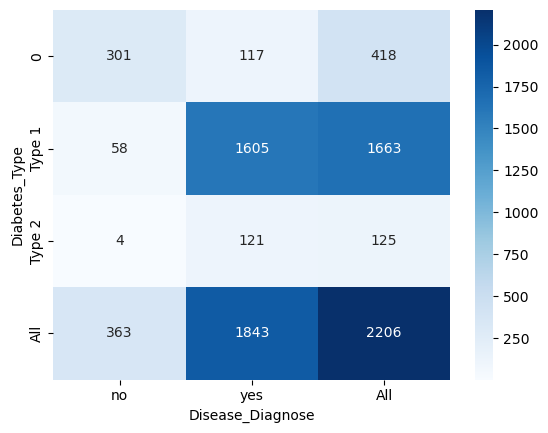

In [20]:
table = pd.crosstab(df['Diabetes_Type'], df['Disease_Diagnose'], margins=True)
sns.heatmap(table, annot=True, fmt="d", cmap='Blues')

Class distribution of diabetes types are not normal at all. Going to have to handle this later
- synthetic oversampling to have equal amounts of t1, t2, and 0?

About 6% of people with T1D have celiac. Compared to the global average of 1%, this is much higher. Elevated risk of celiac disease because both are autoimmune diseases (known genetic link). There is no association or elevated risk with T2D.

# Data Cleaning

Before we build models, we need to drop some features to reduce multicollinearity and data leakage.

In [21]:
df = df.drop(columns=['Marsh', 'cd_type', 'Diabetes'])

In [22]:
df.head(20)

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes
5,8,Female,Type 1,fatty,yes,Variant,yes,yes,1.10,9.5,1.00,yes
6,9,Male,Type 1,watery,yes,Variant,yes,yes,2.10,11.4,1.00,yes
7,5,Female,Type 1,fatty,yes,PSS,yes,yes,0.80,12.0,0.98,yes
8,6,Female,Type 1,fatty,yes,PSS,yes,yes,1.50,8.0,1.10,yes
9,4,Male,Type 1,watery,yes,Variant,yes,yes,0.42,11.5,1.00,yes


# Moving on to the rest of the data prep:

In [23]:
df['Abdominal'] = df['Abdominal'].str.lower()
df['Sticky_Stool'] = df['Sticky_Stool'].str.lower()
df['Weight_loss'] = df['Weight_loss'].str.lower()
df['Disease_Diagnose'] = df['Disease_Diagnose'].str.lower()

In [26]:
df.head()

,Age,Gender,Diabetes_Type,Diarrhea,Abdominal,Short_Stature,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose
0,10,Male,Type 1,inflammatory,yes,PSS,no,no,1.30,10.0,1.00,yes
1,9,Male,Type 1,fatty,yes,PSS,no,no,1.50,12.5,1.30,yes
2,8,Female,Type 1,watery,yes,Variant,yes,yes,0.40,8.0,0.50,yes
3,10,Male,Type 1,watery,yes,PSS,no,no,0.98,9.0,0.66,yes
4,9,Male,Type 1,fatty,yes,PSS,no,no,1.00,10.5,1.10,yes


In [27]:
df['Abdominal'] = np.where(df['Abdominal'] == 'yes', 1, 0)
df["Sticky_Stool"] = np.where(df["Sticky_Stool"] == 'yes', 1, 0)
df["Weight_loss"] = np.where(df["Weight_loss"] == 'yes', 1, 0)
df["Disease_Diagnose"] = np.where(df["Disease_Diagnose"] == 'yes', 1, 0)
df["Gender"] = np.where(df["Gender"] == 'Male', 1, 0)

In [28]:
df = pd.get_dummies(df,drop_first=True)

In [30]:
df.head()

,Age,Gender,Abdominal,Sticky_Stool,Weight_loss,IgA,IgG,IgM,Disease_Diagnose,Diabetes_Type_Type 1,Diabetes_Type_Type 2,Diarrhea_inflammatory,Diarrhea_watery,Short_Stature_PSS,Short_Stature_Variant
0,10,1,1,0,0,1.30,10.0,1.00,1,True,False,True,False,True,False
1,9,1,1,0,0,1.50,12.5,1.30,1,True,False,False,False,True,False
2,8,0,1,1,1,0.40,8.0,0.50,1,True,False,False,True,False,True
3,10,1,1,0,0,0.98,9.0,0.66,1,True,False,False,True,True,False
4,9,1,1,0,0,1.00,10.5,1.10,1,True,False,False,False,True,False


# Moving back to building models:

In [31]:
y = df['Disease_Diagnose']
x = df.drop('Disease_Diagnose', axis=1)

In [32]:
X_main, X_test, y_main, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [33]:
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.125, stratify=y_main, random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
coefficients = log_model.coef_
intercept = log_model.intercept_

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

Coefficients: [[ 0.02613306  0.07180199  1.76584555  0.74144852 -0.47356981 -0.4112764
  -0.01090768  1.2145827   3.85377483  2.55339531 -0.35547809 -0.14914239
   0.36692832 -0.25151511]]
Intercept: [-3.09425985]


In [39]:
log_model.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,

In [40]:
y_pred_log = log_model.predict(X_test)
# evaluate the model
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.68      0.76        73
           1       0.94      0.98      0.96       369

    accuracy                           0.93       442
   macro avg       0.89      0.83      0.86       442
weighted avg       0.92      0.93      0.92       442

[[ 50  23]
 [  9 360]]


In [41]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [47]:
lasso_log = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
lasso_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [49]:
y_pred_lasso = lasso_log.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Coefficients: {lasso_log.coef_}")

Lasso Coefficients: [[ 1.33186678e-02  2.01879642e-04  1.84160802e+00  5.58667891e-01
  -4.33231677e-01 -3.74332004e-01 -4.98492436e-02  1.11431851e+00
   4.15563742e+00  3.16114583e+00 -3.31596336e-01 -1.05193504e-01
   1.84623192e-01 -3.24316196e-01]]


In [51]:
print(classification_report(y_test, y_pred_lasso))
print(confusion_matrix(y_test, y_pred_lasso))

              precision    recall  f1-score   support

           0       0.85      0.68      0.76        73
           1       0.94      0.98      0.96       369

    accuracy                           0.93       442
   macro avg       0.89      0.83      0.86       442
weighted avg       0.92      0.93      0.92       442

[[ 50  23]
 [  9 360]]


In [52]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lasso_log.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print(feature_importance)

                   feature  coefficient
8     Diabetes_Type_Type 1     4.155637
9     Diabetes_Type_Type 2     3.161146
2                Abdominal     1.841608
7                      IgM     1.114319
3             Sticky_Stool     0.558668
4              Weight_loss    -0.433232
5                      IgA    -0.374332
10   Diarrhea_inflammatory    -0.331596
13  Short_Stature_Variant     -0.324316
12       Short_Stature_PSS     0.184623
11         Diarrhea_watery    -0.105194
6                      IgG    -0.049849
0                      Age     0.013319
1                   Gender     0.000202


In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
# Feature importances
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

print(f"Accuracy: {rf.score(X_test, y_test):.3f}")

                   feature  importance
8     Diabetes_Type_Type 1    0.285140
5                      IgA    0.115617
6                      IgG    0.115235
2                Abdominal    0.100750
0                      Age    0.087345
7                      IgM    0.070816
3             Sticky_Stool    0.062208
12       Short_Stature_PSS    0.038945
9     Diabetes_Type_Type 2    0.036827
4              Weight_loss    0.033237
1                   Gender    0.016539
13  Short_Stature_Variant     0.014599
10   Diarrhea_inflammatory    0.012764
11         Diarrhea_watery    0.009979
Accuracy: 0.952
